## 目标与运行方法

下载完整 `.ipynb`，在 VibeIt Studio 文件浏览器中使用 **+ → Import from Files** 导入并打开。按从上到下的顺序运行代码单元；阅读模式中的图表是已保存的真实运行输出。重新运行会从内嵌数据计算结果。

本课适合具备 Python 基础的本科生。先阅读每一步的方法与图注，再修改参数。AI 练习为可选部分，不需要 AI 账号即可完成核心课程。数据写在 notebook metadata 中，不需要另下载数据文件。请保持 notebook 已保存到当前工作文件夹。

学习任务是理解本课的研究问题、执行透明的计算、校验结果，并说明结论的边界。

## 环境与参数

In [1]:
from pathlib import Path
import base64, gzip, hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from IPython.display import display as _display
def display(value):
    if isinstance(value,pd.DataFrame):
        table=value.to_html(max_rows=12,escape=True)
        style="<style>.vibeit-readable-table{max-width:100%;overflow-x:auto}.vibeit-readable-table table{width:max-content;max-width:none;border-collapse:collapse}.vibeit-readable-table td,.vibeit-readable-table th{white-space:nowrap!important;word-break:normal!important;overflow-wrap:normal!important}</style>"
        return _display(HTML(style+'<div class="vibeit-readable-table">'+table+'</div>'))
    return _display(value)
RECIPE_ID='ma03-conditioning'
OUTPUT_DIR=Path.cwd()/"results"/RECIPE_ID
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                      "axes.prop_cycle":plt.cycler(color=["#18785f","#416aa6","#bc6541","#9974a5"])})
print("Python:",platform.python_version(),"; NumPy:",np.__version__,"; Pandas:",pd.__version__)
print("Working folder:",Path.cwd())
print("Core data mode: embedded snapshot; no network requests")


Python: 3.13.13 ; NumPy: 2.5.3 ; Pandas: 3.0.6
Working folder: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads
Core data mode: embedded snapshot; no network requests


### 读取内嵌快照

下面的加载函数按课程 ID 与 SHA-256 在当前文件夹定位本 notebook，解压后再次校验。文件改名不影响匹配。若找不到数据，确认当前工作目录与文件位置；不要用编造的数据替换它。metadata 随 `.ipynb` 保存及导出，复制代码到单独 `.py` 不会自动复制数据。

In [2]:
def load_snapshot(recipe_id, expected_sha256, snapshot_key):
    """Read embedded data from this notebook, including a renamed copy."""
    for path in sorted(Path.cwd().glob("*.ipynb")):
        try:
            notebook = json.loads(path.read_text(encoding="utf-8"))
            metadata = notebook.get("metadata", {}).get("vibeit_cookbook", {})
            blob = metadata.get("snapshots", {}).get(snapshot_key)
            if metadata.get("recipe_id") != recipe_id or not blob:
                continue
            if blob.get("sha256") != expected_sha256:
                continue
            raw = gzip.decompress(base64.b64decode(blob["gzip_base64"], validate=True))
            if hashlib.sha256(raw).hexdigest() != expected_sha256:
                raise ValueError("Embedded snapshot checksum mismatch: " + snapshot_key)
            return json.loads(raw)
        except (OSError, json.JSONDecodeError):
            continue
    raise FileNotFoundError(
        "Save/open the complete .ipynb in the active working folder. "
        "The embedded snapshot could not be located for " + recipe_id)

SNAPSHOT_HASHES={'models': '48fd2e6e706650fe2ee0c0ad80b6d794a546a1dec78dd9d370ac09db3cc3adbf'}
def snapshot(key):
    return load_snapshot(RECIPE_ID,SNAPSHOT_HASHES[key],key)
print("Embedded snapshots:",list(SNAPSHOT_HASHES))


Embedded snapshots: ['models']


### 方法函数

本课所需函数的完整代码就在下面。它们只使用已列出的预装包与标准库，运行时不会导入任何 cookbook 辅助模块。先检查输入约束和返回值；如果修改算法，后面的校验也需要继续通过。

### 数据与模型边界

解析函数与 Monte Carlo 点属于数学教学模型，不是实验测量。使用 Iris 观测时，可交换性和采样设计仍是统计假设；方便样本不自动代表总体。数值离散误差与采样不确定性应分别解释。

## 分步分析

### 1. 构造确定性模型基准

取 [0,1] 上 25 个 x，并令 y=exp(x)。十阶 Vandermonde 矩阵的幂次量级不同。这是解析教学数据，没有隐含测量噪声或统计置信区间。

Design shape: (25, 11) ; condition number: 21503150.614924222


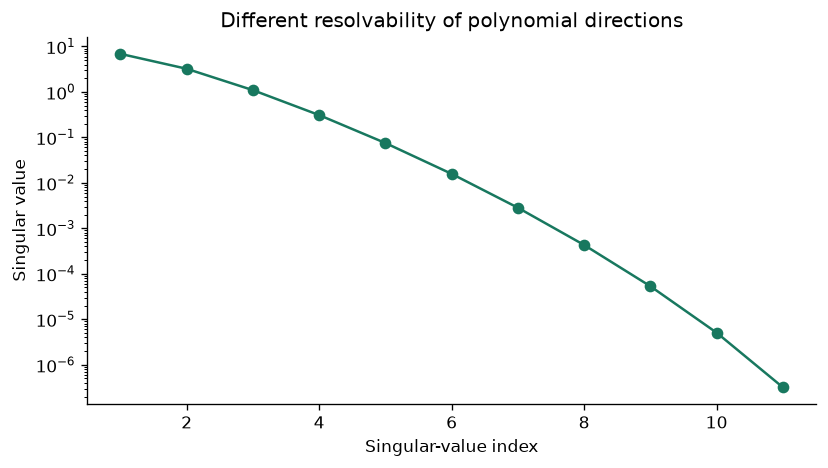

In [3]:
inputs=snapshot("models")
DEGREE=10;x=np.linspace(0,1,25);y=np.exp(x)
design=np.vander(x,DEGREE+1,increasing=True)
singular=np.linalg.svd(design,compute_uv=False);condition=np.linalg.cond(design)
print("Design shape:",design.shape,"; condition number:",condition)
fig,ax=plt.subplots(figsize=(7,4));ax.semilogy(np.arange(1,len(singular)+1),singular,"o-")
ax.set(xlabel="Singular-value index",ylabel="Singular value",title="Different resolvability of polynomial directions");plt.tight_layout();plt.show()


### 2. 用 SVD 求解并比较正规方程

SVD 最小二乘避免平方条件数。对照方法显式求解 AᵀA，即使 A 在数学上满秩也可能不稳定或奇异。应报告失败，不能静默替换结果。

Condition(A): 21503150.614924222 ; condition(A.T @ A): 462238754711098.0
Normal-equation failure: None


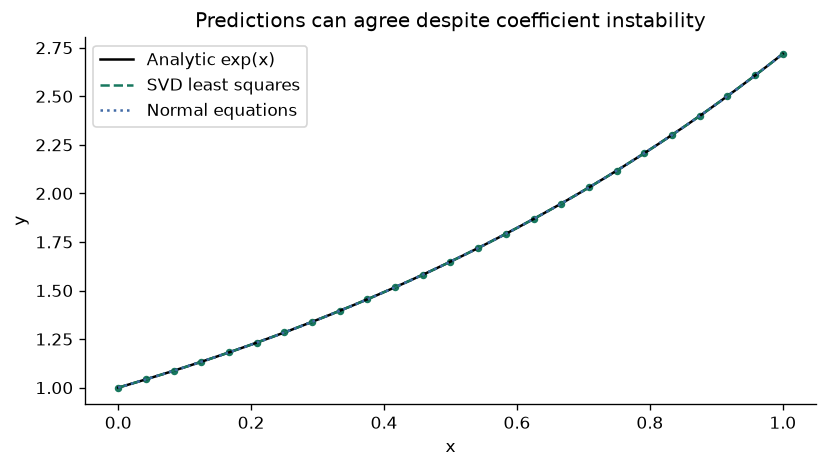

In [4]:
stable=np.linalg.lstsq(design,y,rcond=None)[0]
try:
 normal=np.linalg.solve(design.T@design,design.T@y);normal_failure=None
except np.linalg.LinAlgError as error:
 normal=None;normal_failure=str(error)
print("Condition(A):",condition,"; condition(A.T @ A):",np.linalg.cond(design.T@design))
print("Normal-equation failure:",normal_failure)
dense=np.linspace(0,1,501);dense_design=np.vander(dense,DEGREE+1,increasing=True)
fig,ax=plt.subplots(figsize=(7,4));ax.plot(dense,np.exp(dense),color="black",label="Analytic exp(x)")
ax.plot(dense,dense_design@stable,"--",label="SVD least squares")
if normal is not None:ax.plot(dense,dense_design@normal,":",label="Normal equations")
ax.scatter(x,y,s=12);ax.set(xlabel="x",ylabel="y",title="Predictions can agree despite coefficient instability");ax.legend();plt.tight_layout();plt.show()


### 3. 以记录的尺度扰动响应

加入确定的 10⁻⁸ 量级正弦扰动。比较响应与系数的相对变化，再检查同一插值区间的预测误差。较大的系数变化不一定造成同等预测变化。

Relative response perturbation: 3.900268533006143e-09 ; relative coefficient change: 0.007641567140337687


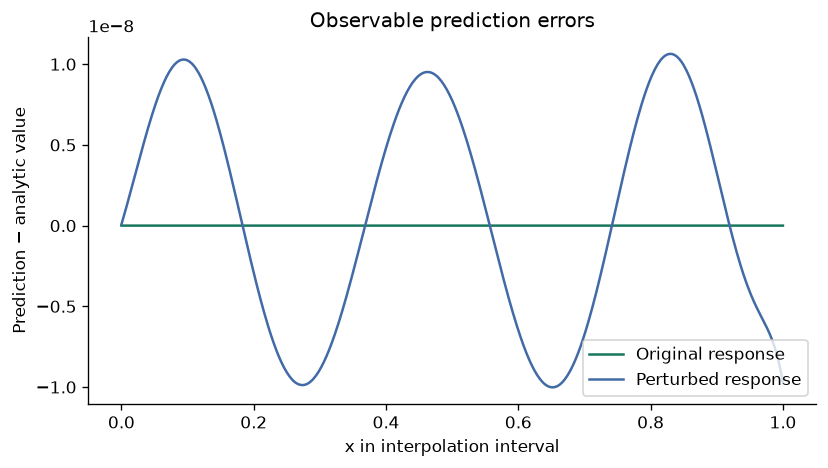

In [5]:
perturbed=y+1e-8*np.sin(17*x)
altered=np.linalg.lstsq(design,perturbed,rcond=None)[0]
relative_input=np.linalg.norm(perturbed-y)/np.linalg.norm(y)
relative_coefficients=np.linalg.norm(altered-stable)/np.linalg.norm(stable)
print("Relative response perturbation:",relative_input,"; relative coefficient change:",relative_coefficients)
fig,ax=plt.subplots(figsize=(7,4));ax.plot(dense,dense_design@stable-np.exp(dense),label="Original response")
ax.plot(dense,dense_design@altered-np.exp(dense),label="Perturbed response")
ax.set(xlabel="x in interpolation interval",ylabel="Prediction − analytic value",title="Observable prediction errors");ax.legend();plt.tight_layout();plt.show()


### 4. 检查正交条件并导出诊断

最小二乘残差应在浮点精度范围内近似正交于设计列。分别记录条件数、求解器、系数向量和观测/预测误差。确定性多项式系数不是因果效应。

In [6]:
residual=design@stable-y
assert np.linalg.norm(design.T@residual)<1e-8
assert np.isfinite(stable).all() and np.max(np.abs(dense_design@stable-np.exp(dense)))<1e-5
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
pd.DataFrame({"power":np.arange(DEGREE+1),"SVD_coefficient":stable,"perturbed_coefficient":altered,"normal_equation_coefficient":normal if normal is not None else np.full(DEGREE+1,np.nan)}).to_csv(OUTPUT_DIR/"coefficients.csv",index=False)
pd.DataFrame({"x":dense,"analytic":np.exp(dense),"SVD_prediction":dense_design@stable,"perturbed_prediction":dense_design@altered}).to_csv(OUTPUT_DIR/"interpolation.csv",index=False)
(OUTPUT_DIR/"diagnostics.json").write_text(json.dumps({"degree":DEGREE,"condition_design":condition,"condition_gram":float(np.linalg.cond(design.T@design)),"relative_input_perturbation":relative_input,"relative_coefficient_change":relative_coefficients,"normal_equation_failure":normal_failure},indent=2))
print("Least-squares checks passed; exports:",OUTPUT_DIR)


Least-squares checks passed; exports: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads/results/ma03-conditioning


## 自主练习与参考答案

1. 为何正规方程可能恶化条件数？
2. 为何系数不稳定而插值仍可能准确？

**参考解释。** 形成 AᵀA 会近似平方条件数。相关基方向可能在预测中相互抵消；系数与预测稳定性是不同目标。

先保留当前 notebook 副本，再修改参数。把新图与原图一起比较，并记录改变了哪些输入、哪些计算和哪些结论。

## 可选的 AI 编程练习

在 VibeIt 的 Coding Agent 中打开当前 notebook，先让助手阅读相关单元。核心课程不依赖 AI 服务；服务可用性与账号设置以应用帮助中心为准。

**提示词 1**

> 仅用 NumPy、Matplotlib 比较三、六、十阶，同时保留解析观测和求解诊断。

**提示词 2**

> 使用同样的包增加中心化/缩放后的多项式基，比较条件数及插值误差。

**人工验收。** 明确记录失败，检查最小二乘正交残差，保持模型数据标注。

检查修改后的源代码，再手动运行受影响单元及后续校验。要求助手解释修改的目的、使用的包和数据来源，并用实际输出核对解释。

## 可选联网扩展

默认关闭下面的联网操作。它只显示数据库版本及快照来源，不会替换核心数据。若要重新获取数据，应另存一个实验版本并记录新的 URL、数据库版本、获取日期与 SHA-256；新版结果需要重新执行和核验。

In [7]:
RUN_ONLINE_UPDATE=False
if RUN_ONLINE_UPDATE:
    import requests
    try:
        response=requests.get('https://docs.scipy.org/doc/scipy/tutorial/integrate.html',timeout=20)
        response.raise_for_status()
        print("Source:",response.url)
        print(response.text[:700])
    except requests.RequestException as error:
        print("Online extension unavailable:",type(error).__name__,str(error)[:160])
else:
    print("Online extension skipped; embedded core data unchanged")


Online extension skipped; embedded core data unchanged


## 来源、快照与下一步

- [IAPWS saturation reference release](https://iapws.org/public/documents/6dGkr/Supp-sat.pdf) — IAPWS SR1-86(1992): unrestricted publication allowed in all countries (cover page); retrieved 2026-10-09. SHA-256 `a10d38d73339b0713c86cfac88f9adcba137202167ccdfa1cd58238c438361d7`.
  Reference equations and numerical coefficients transcribed from release pages 2–3; pedagogical model values are not new experiments.

- [Authored numerical teaching model parameters](https://github.com/zhiluo20/vibeit/blob/main/cookbook-src/freeze_subject_data.py) — Original teaching parameters/code MIT; reference equation coefficients attributed to IAPWS SR1-86(1992); retrieved 2026-10-09. SHA-256 `4350c4305a83c772fa295a8be0ef86a247f2bfaae930a081720d3cd0c753abe0`.
  Declared parameters and seed; generated trajectories and calibration observations must be labelled simulated.


**下一步。** 在保留本课的数据检查、参数记录和结果校验之后，将相同方法用于自己的公开或已获授权数据。记录研究设计与方法限制，不把示例结果当成新实验的验证。完整数据许可与生成说明见 cookbook 网页。